In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!mkdir -p /content/plantdisease_data

In [3]:
# -q: giải nén trong im lặng để không bị lag màn hình
# -d: chỉ định nơi xuất file giải nén ra
!unzip -q "/content/drive/MyDrive/AI/archive.zip" -d /content/plantdisease_data/

In [4]:
!ls /content/plantdisease_data

'new plant diseases dataset(augmented)'   test
'New Plant Diseases Dataset(Augmented)'


In [5]:
import os

# Đường dẫn gốc dẫn thẳng tới thư mục train và valid
TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

print("Đường dẫn Train tồn tại không:", os.path.exists(TRAIN_DIR))
print("Đường dẫn Valid tồn tại không:", os.path.exists(VALID_DIR))

Đường dẫn Train tồn tại không: True
Đường dẫn Valid tồn tại không: True


In [6]:
import os

search_path = '/content/plantdisease_data'
TRAIN_DIR = None
VALID_DIR = None

# Quét tìm tự động
for root, dirs, files in os.walk(search_path):
    if 'train' in dirs and TRAIN_DIR is None:
        TRAIN_DIR = os.path.join(root, 'train')
    if 'valid' in dirs and VALID_DIR is None:
        VALID_DIR = os.path.join(root, 'valid')

print("Đường dẫn TRAIN chính xác là:\n", TRAIN_DIR)
print("-" * 50)
print("Đường dẫn VALID chính xác là:\n", VALID_DIR)

Đường dẫn TRAIN chính xác là:
 /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train
--------------------------------------------------
Đường dẫn VALID chính xác là:
 /content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid


In [7]:
import os

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Tổng số class: {len(classes)} classes")
print("=" * 60)
print(f"{'Tên Class':<40} | {'Train':<7} | {'Valid':<7}")
print("-" * 60)

total_train = 0
total_valid = 0

for class_name in classes:
    train_path = os.path.join(TRAIN_DIR, class_name)
    valid_path = os.path.join(VALID_DIR, class_name)

    # Đếm số file trong mỗi class
    train_count = len(os.listdir(train_path)) if os.path.exists(train_path) else 0
    valid_count = len(os.listdir(valid_path)) if os.path.exists(valid_path) else 0

    total_train += train_count
    total_valid += valid_count

    print(f"{class_name:<40} | {train_count:<7} | {valid_count:<7}")

print("=" * 60)
print(f"TỔNG CỘNG: {total_train} ảnh Train | {total_valid} ảnh Valid")
print(f"TỔNG DATASET: {total_train + total_valid} ảnh")

Tổng số class: 38 classes
Tên Class                                | Train   | Valid  
------------------------------------------------------------
Apple___Apple_scab                       | 2016    | 504    
Apple___Black_rot                        | 1987    | 497    
Apple___Cedar_apple_rust                 | 1760    | 440    
Apple___healthy                          | 2008    | 502    
Blueberry___healthy                      | 1816    | 454    
Cherry_(including_sour)___Powdery_mildew | 1683    | 421    
Cherry_(including_sour)___healthy        | 1826    | 456    
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot | 1642    | 410    
Corn_(maize)___Common_rust_              | 1907    | 477    
Corn_(maize)___Northern_Leaf_Blight      | 1908    | 477    
Corn_(maize)___healthy                   | 1859    | 465    
Grape___Black_rot                        | 1888    | 472    
Grape___Esca_(Black_Measles)             | 1920    | 480    
Grape___Leaf_blight_(Isariopsis_Leaf_Spot) | 1722

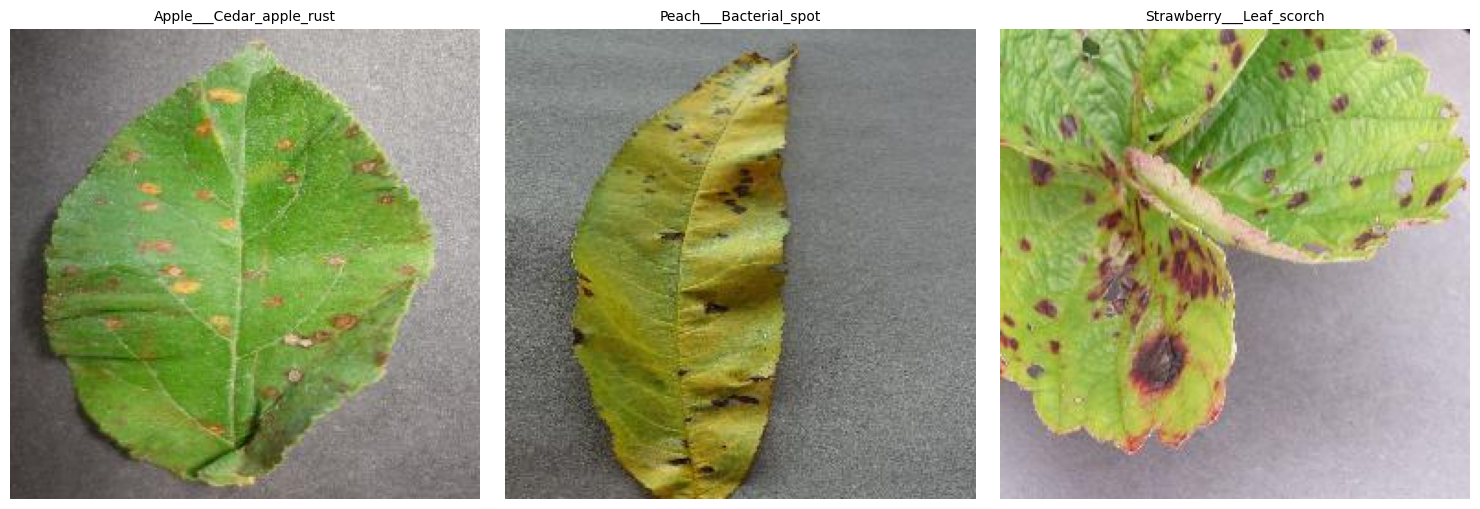

In [8]:
import random
import matplotlib.pyplot as plt
from PIL import Image

# Chọn ngẫu nhiên 3 class bất kỳ để xem thử
random_classes = random.sample(classes, 3)

# Cấu hình khung hiển thị 3 ảnh nằm ngang
plt.figure(figsize=(15, 5))

for i, class_name in enumerate(random_classes):
    class_path = os.path.join(TRAIN_DIR, class_name)
    # Lấy ngẫu nhiên 1 bức ảnh trong class đó
    random_image_name = random.choice(os.listdir(class_path))
    image_path = os.path.join(class_path, random_image_name)

    # Mở ảnh bằng thư viện PIL
    img = Image.open(image_path)

    # Vẽ ảnh lên màn hình bằng Matplotlib
    plt.subplot(1, 3, i + 1)
    plt.imshow(img)
    plt.title(class_name, fontsize=10)
    plt.axis('off') # Ẩn trục tọa độ x, y đi cho đẹp

plt.tight_layout()
plt.show()

Tổng số class: 38



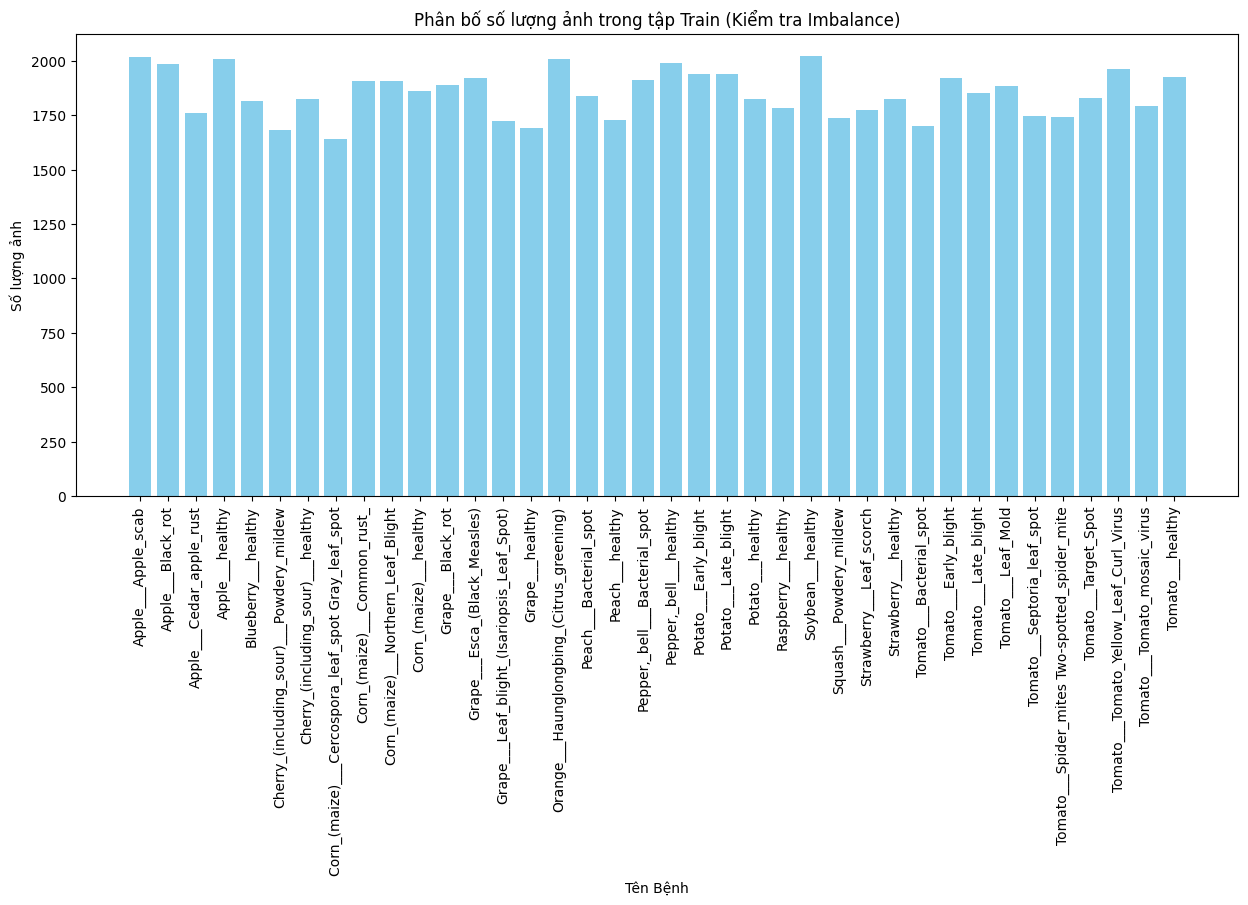

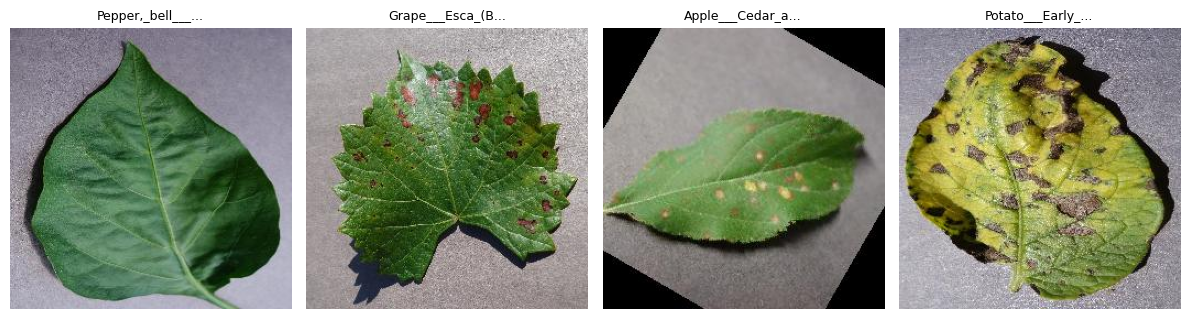

In [9]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Cập nhật đường dẫn thực tế của bạn
TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

classes = sorted(os.listdir(TRAIN_DIR))
print(f"Tổng số class: {len(classes)}\n")

# 1. Đếm số lượng ảnh mỗi class để kiểm tra Imbalance
class_counts = {}
for class_name in classes:
    class_path = os.path.join(TRAIN_DIR, class_name)
    class_counts[class_name] = len(os.listdir(class_path))

# Vẽ biểu đồ phân bố dữ liệu
plt.figure(figsize=(15, 6))
plt.bar(class_counts.keys(), class_counts.values(), color='skyblue')
plt.xticks(rotation=90)
plt.title("Phân bố số lượng ảnh trong tập Train (Kiểm tra Imbalance)")
plt.xlabel("Tên Bệnh")
plt.ylabel("Số lượng ảnh")
plt.show()

# 2. Hiển thị ngẫu nhiên một vài bức ảnh
plt.figure(figsize=(12, 4))
for i, class_name in enumerate(random.sample(classes, 4)):
    class_path = os.path.join(TRAIN_DIR, class_name)
    img_name = random.choice(os.listdir(class_path))
    img = Image.open(os.path.join(class_path, img_name))

    plt.subplot(1, 4, i + 1)
    plt.imshow(img)
    plt.title(class_name[:15] + "...", fontsize=9) # Cắt ngắn tên nếu quá dài
    plt.axis('off')
plt.tight_layout()
plt.show()

Khởi tạo Data Pipeline...
Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.


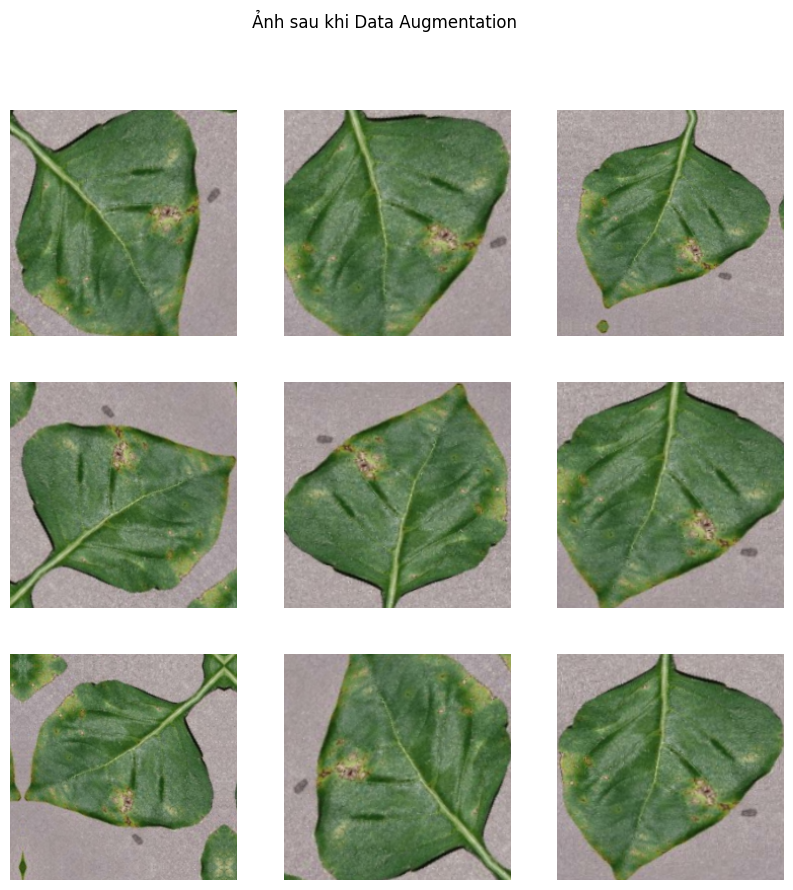

In [10]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

TRAIN_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/train"
VALID_DIR = "/content/plantdisease_data/New Plant Diseases Dataset(Augmented)/New Plant Diseases Dataset(Augmented)/valid"

IMG_SIZE = 224
BATCH_SIZE = 32

print("Khởi tạo Data Pipeline...")
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    shuffle=True,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VALID_DIR,
    shuffle=False,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

# Xây dựng block Data Augmentation & Normalization (Chuẩn hóa)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal_and_vertical"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
], name="data_augmentation")

# Xem thử ảnh sau khi Augmentation
for images, labels in train_ds.take(1):
    plt.figure(figsize=(10, 10))
    for i in range(9):
        augmented_image = data_augmentation(images)
        plt.subplot(3, 3, i + 1)
        plt.imshow(augmented_image[0].numpy().astype("uint8"))
        plt.axis("off")
    plt.suptitle("Ảnh sau khi Data Augmentation")
    plt.show()
    break

In [11]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

# (Giả định bạn đã load train_ds và val_ds ở trên cùng của file này)
IMG_SIZE = 224
num_classes = 38 # Cập nhật theo số lượng class thực tế của bạn

# Xây dựng mô hình CNN tự thiết kế
model_baseline = keras.Sequential([
    layers.Rescaling(1./255, input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    # Không dùng Data Augmentation ở Baseline để xem sức mạnh gốc của model
    layers.Conv2D(32, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, padding='same', activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(num_classes)
])

model_baseline.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Train mô hình
print("BẮT ĐẦU TRAIN MÔ HÌNH BASELINE...")
history_baseline = model_baseline.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

# Lưu mô hình
model_baseline.save('/content/baseline_cnn.keras')

BẮT ĐẦU TRAIN MÔ HÌNH BASELINE...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2197/2197 ━━━━━━━━━━━━━━━━━━━━ 130s 56ms/step - accuracy: 0.7303 - loss: 0.9298 - val_accuracy: 0.8571 - val_loss: 0.4585
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 114s 52ms/step - accuracy: 0.9214 - loss: 0.2498 - val_accuracy: 0.8890 - val_loss: 0.3692
Epoch 3/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 143s 52ms/step - accuracy: 0.9581 - loss: 0.1277 - val_accuracy: 0.8623 - val_loss: 0.5160
Epoch 4/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 118s 54ms/step - accuracy: 0.9728 - loss: 0.0826 - val_accuracy: 0.8704 - val_loss: 0.5377
Epoch 5/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 113s 52ms/step - accuracy: 0.9780 - loss: 0.0677 - val_accuracy: 0.8778 - val_loss: 0.6175
Epoch 6/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 146s 54ms/step - accuracy: 0.9816 - loss: 0.0557 - val_accuracy: 0.8752 - val_loss: 0.6371
Epoch 7/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 142s 54ms/step - accuracy: 0.9839 - loss: 0.0520 - val_accuracy: 0.8672 - val_loss: 0.6606
Epoch 8/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 117s 53ms/step - accuracy: 0.9856 - lo

In [12]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

# (Giả định bạn đã load train_ds và val_ds cùng block data_augmentation)
IMG_SIZE = 224
num_classes = 38

# 1. BƯỚC 1: TRANSFER LEARNING (Đóng băng Base Model)
print("Khởi tạo EfficientNetB0...")
base_model = EfficientNetB0(input_shape=(IMG_SIZE, IMG_SIZE, 3),
                            include_top=False,
                            weights='imagenet')

base_model.trainable = False # Đóng băng các lớp gốc

# Thêm cái "đầu" mới (Classifier) cho bài toán của mình
inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs) # Áp dụng Augmentation
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x) # Chống overfitting
outputs = layers.Dense(num_classes)(x)
model_eff = keras.Model(inputs, outputs)

model_eff.compile(optimizer=keras.optimizers.Adam(1e-3),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

print("BẮT ĐẦU TRANSFER LEARNING...")
history_eff = model_eff.fit(train_ds, validation_data=val_ds, epochs=5)

# 2. BƯỚC 2: FINE TUNING (Mở băng một phần Base Model để học sâu hơn)
print("\nBẮT ĐẦU FINE-TUNING...")
base_model.trainable = True

# Chỉ mở băng 20 layers cuối cùng, giữ nguyên các layer đầu
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Compile lại với learning_rate rất nhỏ để không làm hỏng trọng số cũ
model_eff.compile(optimizer=keras.optimizers.Adam(1e-5),
                  loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
                  metrics=['accuracy'])

history_finetune = model_eff.fit(train_ds, validation_data=val_ds, epochs=10)

# Lưu lại mô hình xịn nhất
model_eff.save('/content/efficientnet_finetuned.keras')
print("Đã lưu mô hình EfficientNet!")

Khởi tạo EfficientNetB0...
16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
BẮT ĐẦU TRANSFER LEARNING...
Epoch 1/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 273s 119ms/step - accuracy: 0.8652 - loss: 0.5691 - val_accuracy: 0.9348 - val_loss: 0.2422
Epoch 2/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 220s 100ms/step - accuracy: 0.9308 - loss: 0.2361 - val_accuracy: 0.9462 - val_loss: 0.1847
Epoch 3/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 258s 98ms/step - accuracy: 0.9426 - loss: 0.1896 - val_accuracy: 0.9504 - val_loss: 0.1586
Epoch 4/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 216s 98ms/step - accuracy: 0.9476 - loss: 0.1694 - val_accuracy: 0.9558 - val_loss: 0.1397
Epoch 5/5
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 216s 98ms/step - accuracy: 0.9501 - loss: 0.1583 - val_accuracy: 0.9558 - val_loss: 0.1379

BẮT ĐẦU FINE-TUNING...
Epoch 1/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 258s 111ms/step - accuracy: 0.8965 - loss: 0.3345 - val_accuracy: 0.9492 - val_loss: 0.1600
Epoch 2/10
2197/2197 ━━━━━━━━━━━━━━━━━━━━ 242s 110ms/step - accuracy: 0.9